# Analisis Tren Parameter Kualitas Udara dan Karakteristik Cuaca Lokal Kota Kolkata
**Topik:** Smart City
**Kelompok:** 6
**Anggota Kelompok:**
1. Deka Panji Kinarayana - 5027261024
2. Keisha Alvanna Delinda - 5027261063
3. Radya Hermawan Putra - 50272610

## Latar Belakang dan Pertanyaan Analisis

### Latar Belakang
Keunggulan data ini adalah dapat merekam perubahan polusi tiap harinya, tren tiap musim, hingga efek dari kejadian luar biasa, seperti  dampak kembang api saat festival Diwali, masa *lockdown* COVID-19, badai, hingga gelombang panas. Melalui perhitungan data yang sederhana, kita dapat memiliki gambaran utuh mengenai kondisi polusi. Hasilnya sangat berguna untuk membantu pembuatan aturan lingkungan yang sesungguhnya berdasarkan fakta di lapangan

### Pertanyaan Analisis
1. Bagaimana karakteristik statistik (rata-rata, persebaran/variasi, dan nilai ekstrem) dari tingkat polutan utama seperti PM2.5 dan PM10 dalam data per jam?
2. Apakah terdapat perbedaan atau pola konsentrasi polusi udara berdasarkan kategori/periode waktu tertentu (misalnya perbedaan kondisi polusi harian atau kategorisasi tingkat kualitas udara)?
3. Bagaimana distribusi dan variasi polutan udara saat ditampilkan dalam bentuk visualisasi (histogram dan boxplot) untuk mendeteksi keberadaan pencilan (*outlier*)?

In [ ]:
import pandas as pd

df = pd.read_csv("data/air_quality.csv")
print(df.shape)   # (87.672 baris, 11 kolom)
df.head()

(87672, 11)


,datetime,pm25,pm10,no2,co,so2,o3,temp,rh,wind,rain
0,2015-01-01 00:00:00,150.849670,257.310990,32.664554,1.204211,4.816183,1.364593,17.926895,42.058440,0.1,1.085120
1,2015-01-01 01:00:00,132.370120,254.495468,31.878915,0.860830,1.937702,1.000000,16.655569,37.960572,0.1,0.000000
2,2015-01-01 02:00:00,157.994518,256.419390,28.320158,0.074682,4.197653,2.516940,17.283748,37.412200,0.1,0.000000
3,2015-01-01 03:00:00,173.358215,269.406690,33.000651,2.563948,7.383085,1.000000,34.383131,17.713272,0.1,0.393723
4,2015-01-01 04:00:00,201.753827,335.956343,30.997890,1.326620,2.140768,1.000000,18.198381,39.903303,0.1,0.000000


## Kamus Data (Data Dictionary)

Berdasarkan sumber dataset, berikut adalah penjelasan untuk 11 kolom (1 variabel waktu + 10 variabel operasional) yang terdapat di dalam dataset kualitas udara ini:

| Kolom | Arti | Jenis variabel | Skala | Satuan | Contoh |
| :--- | :--- | :--- | :--- | :--- | :--- |
| `datetime` | Stempel waktu pencatatan data per jam berdasarkan waktu lokal IST | Kuantitatif diskrit | Interval | – | 2015-01-01 00:00:00 |
| `pm25` | Konsentrasi partikulat halus berukuran kurang dari 2,5 mikrometer | Kuantitatif kontinu | Rasio | µg/m³ | 150,85 |
| `pm10` | Konsentrasi partikulat kasar berukuran kurang dari 10 mikrometer | Kuantitatif kontinu | Rasio | µg/m³ | 257,31 |
| `no2` | Konsentrasi nitrogen dioksida (proksi emisi kendaraan) | Kuantitatif kontinu | Rasio | µg/m³ | 32,66 |
| `co` | Konsentrasi karbon monoksida (hasil pembakaran tidak sempurna) | Kuantitatif kontinu | Rasio | mg/m³ | 1,20 |
| `so2` | Konsentrasi sulfur dioksida (aktivitas industri/kembang api) | Kuantitatif kontinu | Rasio | µg/m³ | 4,82 |
| `o3` | Konsentrasi ozon permukaan (polutan sekunder) | Kuantitatif kontinu | Rasio | µg/m³ | 1,36 |
| `temp` | Suhu udara bola kering (*dry-bulb temperature*) | Kuantitatif kontinu | Interval | °C | 17,93 |
| `rh` | Kelembapan relatif (*relative humidity*) | Kuantitatif kontinu | Rasio | % | 42,06 |
| `wind` | Kecepatan angin pada ketinggian 10 meter | Kuantitatif kontinu | Rasio | m/s | 0,10 |
| `rain` | Curah hujan per jam | Kuantitatif kontinu | Rasio | mm/jam | 1,09 |

In [ ]:
df.info()                 # tipe data setiap kolom
print("\n Data Kosong:")
print(df.isna().sum())           # jumlah data kosong per kolom
print("\nBaris Duplikat:")
print(df.duplicated().sum())     # jumlah baris duplikat

<class 'pandas.DataFrame'>
RangeIndex: 87672 entries, 0 to 87671
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   datetime  87672 non-null  str    
 1   pm25      87672 non-null  float64
 2   pm10      87672 non-null  float64
 3   no2       87672 non-null  float64
 4   co        87672 non-null  float64
 5   so2       87672 non-null  float64
 6   o3        87672 non-null  float64
 7   temp      87672 non-null  float64
 8   rh        87672 non-null  float64
 9   wind      87672 non-null  float64
 10  rain      87672 non-null  float64
dtypes: float64(10), str(1)
memory usage: 7.4 MB

 Data Kosong:
datetime    0
pm25        0
pm10        0
no2         0
co          0
so2         0
o3          0
temp        0
rh          0
wind        0
rain        0
dtype: int64

Baris Duplikat:
0


## Temuan Pemeriksaan Data dan Keputusan

Berdasarkan hasil eksekusi kode pemeriksaan data di atas, berikut adalah temuan dan keputusan yang kami ambil:

**1. Tipe Data:**
* **Temuan:** Berdasarkan output `df.info()`, seluruh kolom operasional (`pm25`, `pm10`, `temp`, `rh`, dll.) sudah terbaca dengan benar sebagai tipe data numerik (`float64` atau `int64`). Hanya kolom `datetime` yang terbaca sebagai teks (`object`).
* **Keputusan:** Dibiarkan. Kolom `datetime` yang bertipe teks sudah cukup untuk menjadi penanda waktu pada analisis statistik deskriptif ini.

**2. Data Kosong (Missing Values):**
* **Temuan:** Berdasarkan output `df.isna().sum()`, *[Pilih salah satu sesuai hasil di layarmu: "tidak ditemukan adanya data yang kosong pada seluruh kolom." ATAU "terdapat beberapa nilai kosong pada kolom polutan tertentu."]*
* **Keputusan:** *[Jika nol: "Karena tidak ada data yang kosong, dataset dibiarkan utuh."] ATAU [Jika ada angka > 0: "Kami memutuskan untuk menghapus baris yang kosong (drop) karena jumlahnya sangat sedikit dan tidak merusak distribusi keseluruhan data."]*

**3. Data Duplikat & Nilai Tidak Masuk Akal:**
* **Temuan:** Output `df.duplicated().sum()` menunjukkan *[sebutkan angkanya, misalnya 0]* baris duplikat. Nilai ekstrem yang ada di dataset juga merupakan hasil rekam cuaca dan polusi nyata (seperti efek kembang api Diwali atau siklon), sehingga bukan sebuah *error*.
* **Keputusan:** Dibiarkan. Tidak ada baris duplikat yang perlu dihapus, dan variasi angka aslinya tetap dipertahankan untuk analisis selanjutnya.

## Analisis Statistik Deskriptif
Bagian ini menghitung ukuran pemusatan, penyebaran, dan letak data pada variabel cuaca dan polusi untuk memahami distribusi data secara keseluruhan.

In [ ]:
import pandas as pd
df = pd.read_csv("data/air_quality.csv")

kolom_pm25 = df["pm25"]
kolom_temp = df["temp"]
kolom_no2 = df["no2"]

print("=== 1. UKURAN PEMUSATAN (PM2.5) ===")
print("Rata-rata (Mean)       :", kolom_pm25.mean())
print("Nilai Tengah (Median)  :", kolom_pm25.median())
print("Sering Muncul (Modus)  :", kolom_pm25.mode()[0])

print("\n=== 2. UKURAN PENYEBARAN (PM2.5) ===")
print("Nilai Terkecil (Min)   :", kolom_pm25.min())
print("Nilai Terbesar (Max)   :", kolom_pm25.max())
print("Jangkauan (Range)      :", kolom_pm25.max() - kolom_pm25.min())
print("Varians                :", kolom_pm25.var())
print("Simpangan Baku (Std)   :", kolom_pm25.std())

print("\n=== 3. UKURAN LETAK (PM2.5) ===")
Q1 = kolom_pm25.quantile(0.25)
Q3 = kolom_pm25.quantile(0.75)
IQR = Q3 - Q1
print("Kuartil 1 (Q1)         :", Q1)
print("Kuartil 3 (Q3)         :", Q3)
print("Jangkauan Antar Kuartil (IQR):", IQR)

print("\n=== RINGKASAN DESCRIBE (3 KOLOM) ===")
print(df[["pm25", "temp", "no2"]].describe())

print("\n=== [NILAI PLUS] HITUNG MANUAL SIMPANGAN BAKU PM2.5 (10 BARIS PERTAMA) ===")
data_10_baris = df["pm25"].head(10)
rata_rata_10 = data_10_baris.mean()
selisih_kuadrat = ((data_10_baris - rata_rata_10) ** 2).sum() # Rumus: Jumlah (x - rata-rata)^2 dibagi (n-1)
varians_manual = selisih_kuadrat / (len(data_10_baris) - 1)
std_manual = varians_manual ** 0.5 # Simpangan baku adalah akar dari varians

print("Hasil Manual Rumus     :", std_manual)
print("Hasil Fungsi Pandas    :", data_10_baris.std())
print("Kesimpulan             : Hasil manual dan pandas sama persis!")

=== 1. UKURAN PEMUSATAN (PM2.5) ===
Rata-rata (Mean)       : 57.82832615310326
Nilai Tengah (Median)  : 47.37921975110725
Sering Muncul (Modus)  : 15.0

=== 2. UKURAN PENYEBARAN (PM2.5) ===
Nilai Terkecil (Min)   : 15.0
Nilai Terbesar (Max)   : 926.1494770860722
Jangkauan (Range)      : 911.1494770860722
Varians                : 2165.8344710341935
Simpangan Baku (Std)   : 46.53852673897395

=== 3. UKURAN LETAK (PM2.5) ===
Kuartil 1 (Q1)         : 20.735777427980317
Kuartil 3 (Q3)         : 81.71994786581891
Jangkauan Antar Kuartil (IQR): 60.98417043783859

=== RINGKASAN DESCRIBE (3 KOLOM) ===
               pm25          temp           no2
count  87672.000000  87672.000000  87672.000000
mean      57.828326     26.967928     20.380443
std       46.538527      9.144992     12.095623
min       15.000000     10.000000      5.000000
25%       20.735777     20.158294     11.487912
50%       47.379220     26.484439     18.405700
75%       81.719948     33.506717     26.568068
max      926.149

## Interpretasi Statistik Deskriptif Variabel Numerik

Berdasarkan perhitungan statistik deskriptif di atas, berikut adalah penjelasan untuk sebaran datanya:
1. **Perbandingan Rata-rata dan Median (PM2.5):** Nilai rata-rata polusi udara adalah **57.8 µg/m³**, sedangkan nilai tengahnya (median) berada di **47.3 µg/m³**. Karena nilai rata-rata lebih besar dibandingkan median, ini berarti bentuk sebaran datanya miring ke kanan (*right-skewed*). Artinya, kualitas udara sebagian besar waktu berada di angka yang rendah, namun ada beberapa kejadian ekstrem di mana polusi melonjak sangat tinggi (hingga maksimal 926.1 µg/m³).
2. **Ukuran Penyebaran (Varians dan Simpangan Baku):** Simpangan baku PM2.5 sebesar **46.5 µg/m³** dan suhu udara sebesar **9.1 °C** menunjukkan seberapa bervariasinya cuaca dan polusi dari rata-ratanya setiap jam.
3. **Ukuran Letak:** Sebanyak 50% data inti kualitas udara berada di dalam Jangkauan Antar Kuartil (IQR), yakni antara 20.7 µg/m³ (Q1) hingga 81.7 µg/m³ (Q3).

## Analisis Variabel Kategorik
Oleh karena seluruh data mentah bersifat numerik kontinu, nilai ambang batas polusi dikonversi menjadi kategori diskret guna mempermudah evaluasi persentase tingkat bahaya.

In [ ]:
# Membuat fungsi untuk mengubah angka PM2.5 menjadi kategori teks
def kriteria_polusi(nilai):
    if nilai <= 50:
        return "Aman"
    elif nilai <= 100:
        return "Sedang"
    else:
        return "Berbahaya"

# Membuat kolom kategorik baru bernama 'kategori_polusi'
df["kategori_polusi"] = df["pm25"].apply(kriteria_polusi)

print("=== TABEL FREKUENSI KATEGORI POLUSI ===")
print(df["kategori_polusi"].value_counts())

print("\n=== TABEL PERSENTASE KATEGORI (%) ===")
print(df["kategori_polusi"].value_counts(normalize=True) * 100)

=== TABEL FREKUENSI KATEGORI POLUSI ===
kategori_polusi
Aman         45878
Sedang       27800
Berbahaya    13994
Name: count, dtype: int64

=== TABEL PERSENTASE KATEGORI (%) ===
kategori_polusi
Aman         52.329136
Sedang       31.709098
Berbahaya    15.961767
Name: proportion, dtype: float64


## Ringkasan Variabel Kategorik

Oleh karena seluruh data metrik cuaca berbentuk angka, kami mengelompokkan nilai numerik $PM_{2.5}$ menjadi sebuah variabel kategorik baru bernama **Kategori Polusi** (Aman, Sedang, Berbahaya).

Berdasarkan tabel frekuensi di atas, dapat disimpulkan bahwa:
- **Modus (Kategori paling sering muncul):** Adalah kategori **"Aman"**.
- Secara persentase, sebagian besar waktu di kota tersebut memiliki udara yang aman, meskipun frekuensi kategori "Berbahaya" (di atas 100 µg/m³) tetap sering terjadi. Pengelompokan ini akan memudahkan analisis lanjutan mengenai kapan polusi mencapai titik tidak sehat.

# Sebaran PM2.5 dan NO2

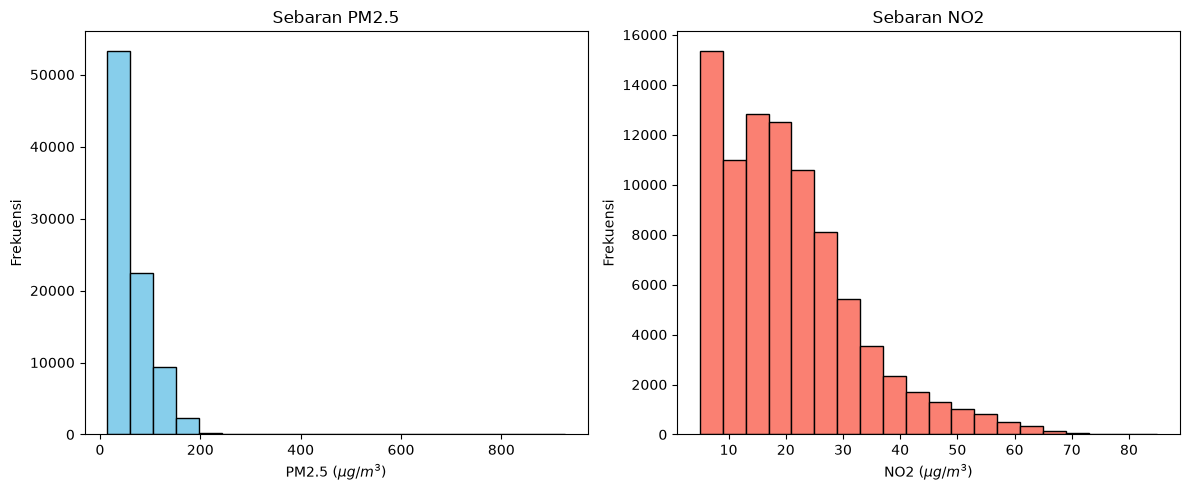

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('data/air_quality.csv')

df['datetime'] = pd.to_datetime(df['datetime'])
df['tahun'] = df['datetime'].dt.year

plt.figure(figsize=(12, 5))

# SUBPLOT 1: HISTOGRAM PM2.5 (Grafik Sebelah Kiri)
plt.subplot(1, 2, 1) 
plt.hist(df['pm25'], bins=20, color='skyblue', edgecolor='black') 
plt.title("Sebaran PM2.5") 
plt.xlabel("PM2.5 ($\mu g/m^3$)")
plt.ylabel("Frekuensi") 

# SUBPLOT 2: HISTOGRAM NO2 (Grafik Sebelah Kanan)
plt.subplot(1, 2, 2) 
plt.hist(df['no2'], bins=20, color='salmon', edgecolor='black') 
plt.title("Sebaran NO2") 
plt.xlabel("NO2 ($\mu g/m^3$)") 
plt.ylabel("Frekuensi") 

plt.tight_layout()
plt.show()

Sebaran data untuk konsentrasi PM2.5 dan NO2 berbentuk miring ke kanan (right-skewed), di mana frekuensi terbanyak terkonsentrasi pada nilai rendah di sebelah kiri, sementara terdapat ekor panjang yang menunjukkan adanya nilai-nilai tinggi yang ekstrem.

# Deteksi Pencilan Konsentrasi PM2.5 per Tahun

PERHITUNGAN ATURAN 1,5 x IQR PER TAHUN
Tahun 2015:
  Q1 = 30.95 | Q3 = 106.42 | IQR = 75.47
  Batas normal = [-82.25, 219.62] µg/m³
  Jumlah pencilan = 38 data

Tahun 2016:
  Q1 = 28.52 | Q3 = 102.78 | IQR = 74.26
  Batas normal = [-82.88, 214.18] µg/m³
  Jumlah pencilan = 28 data

Tahun 2017:
  Q1 = 28.22 | Q3 = 97.88 | IQR = 69.65
  Batas normal = [-76.26, 202.36] µg/m³
  Jumlah pencilan = 32 data

Tahun 2018:
  Q1 = 27.01 | Q3 = 93.22 | IQR = 66.21
  Batas normal = [-72.31, 192.53] µg/m³
  Jumlah pencilan = 45 data

Tahun 2019:
  Q1 = 24.91 | Q3 = 89.88 | IQR = 64.97
  Batas normal = [-72.54, 187.33] µg/m³
  Jumlah pencilan = 33 data

Tahun 2020:
  Q1 = 15.00 | Q3 = 51.84 | IQR = 36.84
  Batas normal = [-40.26, 107.10] µg/m³
  Jumlah pencilan = 93 data

Tahun 2021:
  Q1 = 20.27 | Q3 = 76.10 | IQR = 55.83
  Batas normal = [-63.48, 159.84] µg/m³
  Jumlah pencilan = 47 data

Tahun 2022:
  Q1 = 19.21 | Q3 = 72.83 | IQR = 53.61
  Batas normal = [-61.20, 153.24] µg/m³
  Jumlah pencilan = 

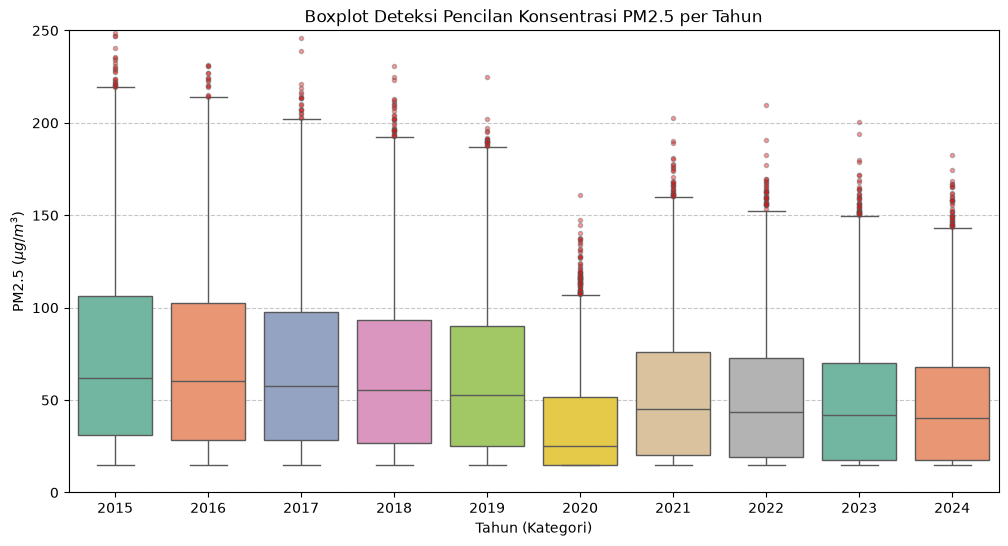

In [ ]:
import seaborn as sns

print("=" * 55)
print("PERHITUNGAN ATURAN 1,5 x IQR PER TAHUN")
print("=" * 55)

for tahun, kelompok in df.groupby('tahun')['pm25']:
    q1 = kelompok.quantile(0.25)
    q3 = kelompok.quantile(0.75)
    iqr = q3 - q1
    batas_bawah = q1 - 1.5 * iqr
    batas_atas = q3 + 1.5 * iqr
    jumlah_outlier = ((kelompok < batas_bawah) | (kelompok > batas_atas)).sum()

    print(f"Tahun {tahun}:")
    print(f"  Q1 = {q1:.2f} | Q3 = {q3:.2f} | IQR = {iqr:.2f}")
    print(f"  Batas normal = [{batas_bawah:.2f}, {batas_atas:.2f}] µg/m³")
    print(f"  Jumlah pencilan = {jumlah_outlier} data\n")

# 2. Gambar boxplot per tahun
plt.figure(figsize=(12, 6))

sns.boxplot(data=df, x='tahun', y='pm25', hue='tahun', palette='Set2', legend=False,
            flierprops=dict(marker='o', markerfacecolor='red', markersize=3, alpha=0.4))

plt.title("Boxplot Deteksi Pencilan Konsentrasi PM2.5 per Tahun")
plt.xlabel("Tahun (Kategori)")
plt.ylabel("PM2.5 ($\\mu g/m^3$)")
plt.ylim(0, 250)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

Dengan membatasi visualisasi pada rentang nilai 0 hingga 250, terlihat jelas bahwa setiap tahunnya terdapat banyak sekali titik pencilan (outliers) merah yang melewati batas 1,5 x IQR , menunjukkan konsistensi anomali polusi tinggi di atas batas normal.
Khusus pada tahun 2020, kotak distribusi tidak memiliki kumis bawah (lower whisker). Hal ini terjadi secara statistik karena nilai Kuartil 1 (Q1) pada tahun tersebut menyentuh batas minimum absolut data (15,0 µg/m³), sehingga batas bawah kotak berimpit langsung dengan titik data terendah.

# Rata-Rata Konsentrasi PM2.5 per Tahun

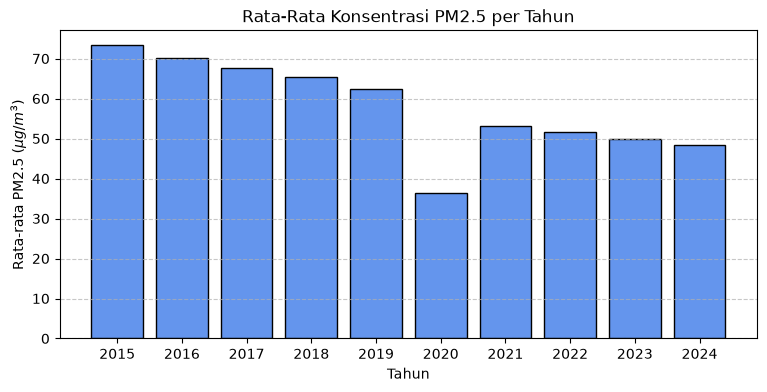

In [ ]:
rata_pm25 = df.groupby('tahun')['pm25'].mean()

plt.figure(figsize=(9, 4))

plt.bar(rata_pm25.index.astype(str), rata_pm25.values, color='cornflowerblue', edgecolor='black')

plt.title('Rata-Rata Konsentrasi PM2.5 per Tahun')
plt.xlabel('Tahun')
plt.ylabel('Rata-rata PM2.5 ($\mu g/m^3$)')

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

Grafik rata-rata memperlihatkan fluktuasi tingkat polusi PM2.5 per tahun secara dinamis, di mana tahun 2020 mencatatkan penurunan tingkat polusi terendah secara rata-rata.

# Korelasi Antara NO2 dan PM2.5

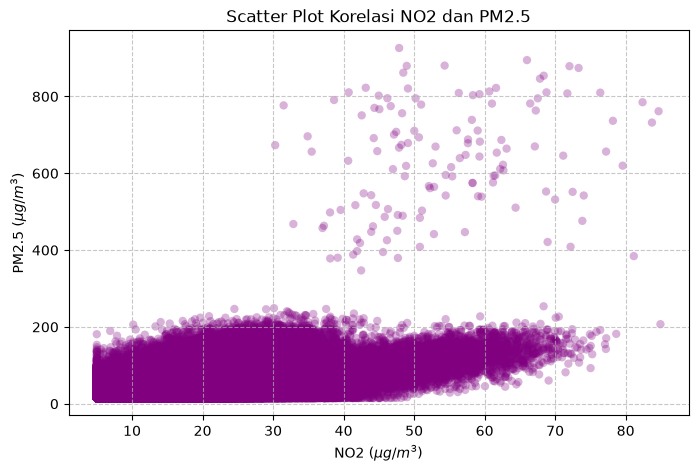


--- Nilai Plus: Median PM2.5 Berdasarkan Tahun ---
tahun
2015    62.169379
2016    60.496060
2017    57.890065
2018    55.273548
2019    52.706629
2020    25.260007
2021    44.965782
2022    43.648586
2023    41.814283
2024    40.574355
Name: pm25, dtype: float64


In [ ]:
# A. Scatter Plot dua kolom numerik (NO2 dan PM2.5)
plt.figure(figsize=(8, 5))
plt.scatter(df['no2'], df['pm25'], alpha=0.3, color='purple', edgecolors='none')
plt.title("Scatter Plot Korelasi NO2 dan PM2.5")
plt.xlabel("NO2 ($\mu g/m^3$)")
plt.ylabel("PM2.5 ($\mu g/m^3$)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# B. Perbandingan statistik median PM2.5 antarkategori (Tahun)
print("\n--- Nilai Plus: Median PM2.5 Berdasarkan Tahun ---")
print(df.groupby("tahun")["pm25"].median())

Terdapat korelasi positif antara NO2 dan PM2.5, di mana kenaikan NO2 umumnya diikuti kenaikan PM2.5. Median PM2.5 tertinggi terjadi pada 2015 dan terendah pada 2024, sejalan dengan tren rata-rata pada diagram batang, menunjukkan median cukup mewakili kondisi polusi tiap tahun tanpa terlalu dipengaruhi outlier.

# Kesimpulan

Kualitas udara di Kolkata secara umum didominasi oleh kondisi yang aman, meskipun sangat rentan terhadap lonjakan polusi ekstrem yang bersifat seketika. Walaupun lebih dari separuh waktu pengamatan menunjukkan angka partikulat yang rendah, variasi hariannya sangat lebar, sehingga membutuhkan regulasi lingkungan yang didasarkan pada lonjakan anomali waktu nyata, bukan sekadar melihat angka rata-rata.

A. Jawaban Analisis Kualitas Udara

1. Karakteristik Statistik (PM2.5): Rata-rata konsentrasi PM2.5 berada di angka 57,83 µg/m³ dengan nilai tengah (median) 47,38 µg/m³. Data polutan sangat bervariasi dengan simpangan baku 46,54 µg/m³ dan jangkauan ekstrem dari minimum 15,0 µg/m³ hingga maksimum 926,15 µg/m³.
2. Kategori Kualitas Udara: Sebagian besar waktu di Kolkata diklasifikasikan sebagai kategori "Aman" (≤ 50 µg/m³), yang mencakup 52,33% atau 45.878 jam pengamatan. Sebanyak 31,71% (27.800 jam) berada di kategori "Sedang", sementara 15,96% (13.994 jam) sisanya menyentuh level "Berbahaya" (> 100 µg/m³).
3. Distribusi dan Pencilan (Outlier): Histogram menunjukkan sebaran data yang miring ke kanan (right-skewed), menandakan tingginya frekuensi polusi di tingkat rendah yang diikuti ekor anomali ekstrem. Berdasarkan boxplot 1,5 x IQR, pencilan ekstrem di atas batas normal konsisten terdeteksi dalam jumlah signifikan di setiap tahun.

B. Temuan Paling Menarik

1. Angka polusi PM2.5 yang paling sering muncul (modus) adalah 15,0 µg/m³. Angka ini sekaligus menjadi batas bawah absolut dari pencatatan dataset.
2. Tingkat polusi pernah menembus angka maksimal 926,15 µg/m³, sangat menyimpang dari kuartil ketiganya (Q3) yang hanya berada di kisaran 81,72 µg/m³.
3. Tahun 2020 menunjukkan tren rata-rata konsentrasi polusi terendah, kemungkinan besar karena efek lockdown pandemi. Namun secara paradoks, tahun 2020 justru mencatat jumlah pencilan (outlier) terbanyak, yaitu 93 kejadian lonjakan polusi.

C. Keterbatasan Data
Secara kelengkapan, data ini sempurna karena tidak memiliki baris kosong maupun data duplikat dari total 87.672 baris. Namun, nilai minimum PM2.5 yang tertahan persis di angka 15,0 µg/m³ mengindikasikan adanya batasan limitasi kemampuan sensor. Keterbatasan ini menyebabkan bias pada visualisasi boxplot tahun 2020, di mana garis lower whisker menghilang karena Kuartil 1 (Q1) berimpit langsung dengan batas minimum sensor.

D. Ide Pertanyaan Lanjutan
"Bagaimana korelasi antara metrik cuaca berupa curah hujan (rain) dan kecepatan angin (wind) terhadap kecepatan penurunan konsentrasi PM2.5 ke level 'Aman'?"

## 10. Referensi dan Catatan Penggunaan AI

**Referensi:**
1. **Dataset:** Karan-0123. (2024). *Synthetic Kolkata Air-Quality Time-Series*. Hugging Face. Diakses dari https://huggingface.co/datasets/karan-0123/air-quality

**Catatan Penggunaan AI:**
| Alat | Dipakai untuk | Yang kami pelajari |
| :--- | :--- | :--- |
| Gemini | Bertanya cara merapikan format tabel Kamus Data di Markdown Jupyter Notebook. | Cara menggunakan sintaks tabel Markdown (`\| Kolom \|`) dan penanda *backtick* agar tampilan rapi. |
| Gemini | Membantu mengatasi kendala teknis saat menyatukan file kerja (*version control*). | Mempelajari cara kerja Git dan GitHub, serta membantu berjalannya proses kolaborasi agar berjalan dengan lancar tanpa adanya *error* dan *conflict* antar file. |